MODEL FOR FLOOD DETECTION

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Load Data and Preprocessing

In [ ]:
input_dataset = "/content/drive/MyDrive/Flood/Flood data"
output_dataset = "/content/drive/MyDrive/preprocessedFlood"

img_size = 128

In [ ]:
if not os.path.exists(output_dataset):
    os.makedirs(output_dataset)

In [ ]:
for root, dirs, files in os.walk(input_dataset):

    # create same folder structure in output
    relative_path = os.path.relpath(root, input_dataset)
    save_folder = os.path.join(output_dataset, relative_path)

    os.makedirs(save_folder, exist_ok=True)

    print("Processing:", root)

    for file in tqdm(files):

        if file.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(root, file)

            try:
                # read image
                img = cv2.imread(img_path)

                if img is None:
                    continue

                # convert to RGB (important)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # resize
                img = cv2.resize(img, (img_size, img_size))

                # normalize
                img = img / 255.0

                # save (convert back to 0–255)
                save_path = os.path.join(save_folder, file)
                cv2.imwrite(save_path, (img * 255).astype("uint8"))

            except Exception as e:
                print("Error:", img_path)

Processing: /content/drive/MyDrive/Flood/Flood data


0it [00:00, ?it/s]


Processing: /content/drive/MyDrive/Flood/Flood data/Test


0it [00:00, ?it/s]


Processing: /content/drive/MyDrive/Flood/Flood data/Test/Flood


...

0it [00:00, ?it/s]


Processing: /content/drive/MyDrive/Flood/Flood data/Train/Flood


100%|██████████| 1400/1400 [02:25<00:00,  9.64it/s]


Processing: /content/drive/MyDrive/Flood/Flood data/Train/Not Flood


100%|██████████| 600/600 [01:24<00:00,  7.12it/s]


In [ ]:
train_path = "/content/drive/MyDrive/preprocessedFlood/Train"
test_path  = "/content/drive/MyDrive/preprocessedFlood/Test"

img_size = 128
batch_size = 30

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_path = "/content/drive/MyDrive/preprocessedFlood/Test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=30,
    class_mode='categorical',
    shuffle=False
)

Found 574 images belonging to 2 classes.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 2000 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 574 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)

{'Flood': 0, 'Not Flood': 1}


In [ ]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2,activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=17
)

Epoch 1/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 770ms/step - accuracy: 0.7295 - loss: 0.5471
Epoch 2/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 769ms/step - accuracy: 0.7625 - loss: 0.4740
Epoch 3/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 55s 825ms/step - accuracy: 0.8040 - loss: 0.4244
Epoch 4/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 53s 794ms/step - accuracy: 0.8195 - loss: 0.4020
Epoch 5/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 763ms/step - accuracy: 0.8230 - loss: 0.3793
Epoch 6/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 762ms/step - accuracy: 0.8525 - loss: 0.3403
Epoch 7/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 766ms/step - accuracy: 0.8535 - loss: 0.3367
Epoch 8/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 51s 756ms/step - accuracy: 0.8690 - loss: 0.3031
Epoch 9/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 771ms/step - accuracy: 0.8725 - loss: 0.2990
Epoch 10/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 51s 755ms/step - accuracy: 0.8780 - loss: 0.2873
Epoch 11/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 51s 763ms/step - accuracy: 0.8550 - loss: 0.3272
Epoch 12/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 50

In [ ]:
model.save("/content/drive/MyDrive/major/Flood_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/major/Flood_model.h5")

In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step - accuracy: 0.7613 - loss: 0.7282
Test Accuracy: 0.7613240480422974


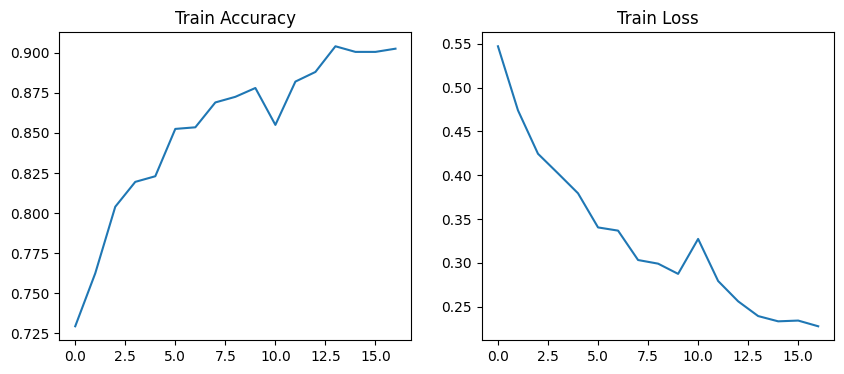

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title("Train Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title("Train Loss")

plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step


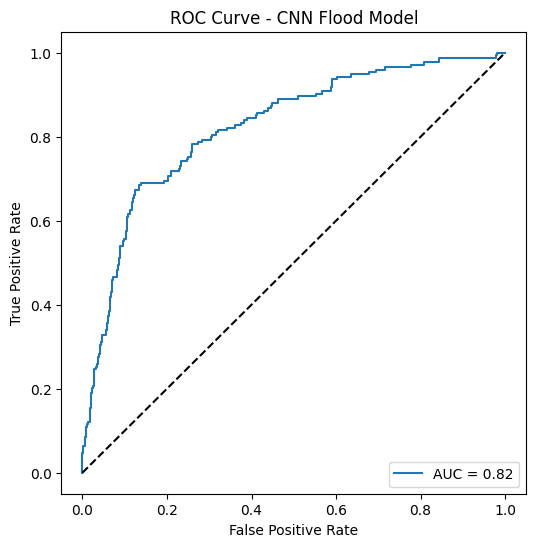

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

test_data.reset()

y_pred_prob = model.predict(test_data)

y_true = test_data.classes

y_pred_prob = y_pred_prob[:,1]

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Flood Model")
plt.legend(loc="lower right")
plt.show()

In [ ]:
test_data.reset()
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 453ms/step


In [ ]:
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

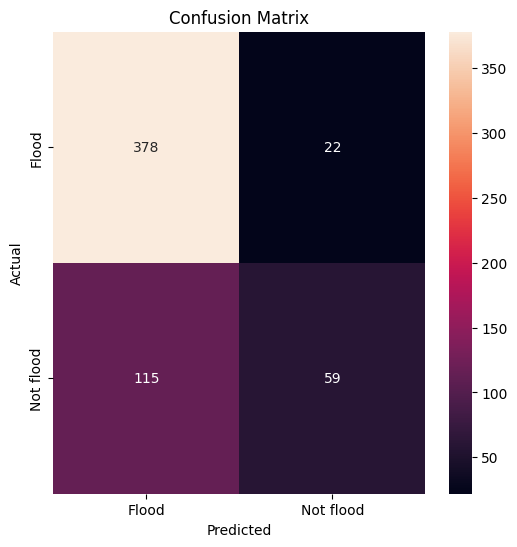

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

       Flood       0.77      0.94      0.85       400
   Not flood       0.73      0.34      0.46       174

    accuracy                           0.76       574
   macro avg       0.75      0.64      0.65       574
weighted avg       0.76      0.76      0.73       574

